# Feature and Model Selection

In [104]:
import seaborn as sns
import warnings
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Classical ML models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Gradient boosting libraries
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import sys 
sys.path.append('..')  

from module.dataload import DPN_data
import ymlconfig
from utils2.selection import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

warnings.filterwarnings('ignore')
np.set_printoptions(precision=3)  # decimal places for outputs from numpy
pd.set_option("display.precision", 3)  # decimal places for outputs from pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


----

## Read Config File

In [105]:
config_path = Path(r'experiments\binary')
#config_file = config_path / "selection_config_dev.yml"
config_file = config_path / "selection_config_final.yml"
config_dict = ymlconfig.load_config(config_file)
config = ymlconfig.dict_to_namespace(config_dict)
config_dict

{'experiment': {'summary': 'binary classification - feature  and model selection (final experiment)',
  'classification_type': 'binary',
  'stage': 'feature_model_selection',
  'tag': 'final',
  'verbosity': 0,
  'random_seed': 42},
 'data': {'dataset_path': '../dataset/Sudoscan Working File with Stats.xlsx'},
 'feature_selection': {'cross_validation': {'k_splits': 4,
   'n_repeats': 10,
   'scoring': 'youden'},
  'vif_threshold': 5},
 'figures': {'summary_metric': 'youden', 'summary_table_topk': 5}}

## Data Loading

In [106]:
D = DPN_data(config.data.dataset_path)
D.load(classification=config.experiment.classification_type);
D.df.tail(3)

,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS,Confirmed_Binary_DPN
187,1,36.0,0,1.0,1.0,6.18,1,0,0,1,0,0,1,0,1,3.0,11.45,49.2,13.79,40.2,41.8,3.60,11.94,8.78,50.3,14.11,43.1,14.95,41.2,42.2,3.7,9.43,7.19,49.9,69.0,4.0,56.0,8.0,83.0,7.0,0
188,0,60.0,1,5.0,1.0,12.20,1,0,1,0,0,1,1,1,1,8.0,5.03,37.9,0.00,0.0,36.3,4.85,5.05,3.06,53.1,5.58,37.2,0.00,0.0,32.2,4.2,5.09,3.28,53.5,16.0,11.0,21.0,9.0,46.0,32.0,1
189,0,65.0,1,15.0,1.0,7.59,1,1,0,1,0,1,1,1,1,8.0,0.00,0.0,0.00,0.0,43.2,5.80,0.56,0.20,0.0,0.00,0.0,0.00,0.0,48.1,5.7,0.27,0.11,0.0,39.0,16.0,41.0,23.0,43.0,44.0,1


Binary Classification Classes:  ['Negative', 'Possible', 'Probable'] vs 'Confirmed'


In [107]:
dfdpn = D.df
data_cols = dfdpn.drop(D.non_data_cols, axis=1, errors="ignore").columns
len(data_cols), data_cols

(40,
 Index(['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C', 'HPN', 'PAOD',
        'DSLPDMIA', 'CKD', 'GBS', 'DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR',
        'MNSI', 'SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L',
        'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R',
        'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R',
        'FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM',
        'NS', 'CAS'],
       dtype='object'))

### Data Inspection

In [108]:
X = dfdpn[data_cols]
y = dfdpn['Confirmed_Binary_DPN']
X.shape, y.shape

((190, 40), (190,))

In [109]:
# get number of postive and negative class
print('Confirmed - positive class', y.sum())
print('Non-confirmed - negative class', y.shape[0]-y.sum())

Confirmed - positive class 130
Non-confirmed - negative class 60


----

## Global Variables

In [110]:
model_metrics = {}  # key: experiment code, value: {model: <string> (e.g. all, ncs), rcv_cores: <Dataframe> Perfomance metrics of repeated k-fold of algorithms}
metrics_stats = {}   # key: experiment code, value: {stat: <string> (e.g. mean, std), stat (mean/std) of the performance of all algorithms}
youden_scores  = {} # key: experiment code, value: list of youden cv scores algorithms

In [111]:
random_seed = config.experiment.random_seed
verbosity = config.experiment.verbosity

k_splits = config.feature_selection.cross_validation.k_splits
n_repeats = config.feature_selection.cross_validation.n_repeats
scoring = config.feature_selection.cross_validation.scoring
vif_threshold = config.feature_selection.vif_threshold
experiment_tag = config.experiment.tag

outputdir = config_path /  config.experiment.tag / config.experiment.stage
outputdir.mkdir(parents=True, exist_ok=True)
print(outputdir)

experiments\binary\final\feature_model_selection


## Iterative Group Feature Elimination

----

### All Features

In [112]:
model_metrics['All'] = benchmark_models(X, y, k_splits, n_repeats, random_seed, 1, experiment_tag) # 1 = verbosity

⏩ Naive: No scaling applied.
⚙️ Logistic Regression: Scaling continuous cols with StandardScaler
⚙️ LDA: Scaling continuous cols with StandardScaler
⚙️ QDA: Scaling continuous cols with StandardScaler
⏩ SGDClassifier: No scaling applied.
⏩ Decision Tree: No scaling applied.
⏩ Random Forest: No scaling applied.
⏩ Extra Trees: No scaling applied.
⏩ Gradient Boosting: No scaling applied.
⏩ XGBoost: No scaling applied.
⏩ LightGBM: No scaling applied.
⏩ CatBoost: No scaling applied.
⚙️ kNN: Scaling continuous cols with MinMaxScaler
⚙️ Naive Bayes: Scaling continuous cols with StandardScaler
⚙️ Linear SVM: Scaling continuous cols with StandardScaler
⚙️ RBF SVM: Scaling continuous cols with StandardScaler


In [113]:
model_metrics['All'] # list of dictionary with 2 keys, model and scores (a dataframe)

[{'model': 'Naive',
  'rcv_scores':     accuracy  precision  sensitivity  specificity  youden     f1  roc-auc
  0      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  1      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  2      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  3      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  4      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  5      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  6      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  7      0.681      0.681          1.0          0.0     0.0  0.810      0.5
  8      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  9      0.688      0.688          1.0          0.0     0.0  0.815      0.5
  10     0.681      0.681          1.0          0.0     0.0  0.810      0.5
  11     0.681      0.681          1.0          0.0   

In [114]:
model_metrics.keys() # only experiment named 'All'  loaded so far 

dict_keys(['All'])

In [115]:
len(model_metrics['All']) # number of algorithms

16

In [116]:
model_metrics['All'][0]['model'] # Get model name of algo 0

'Naive'

In [117]:
# get scores for algo 1 (Logistic Regression)   
# expect k*N_REPEATS rows (e.g. 10 for k=5, NREPEATS=2)

model_metrics['All'][1]['rcv_scores'] 

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
0,0.917,0.968,0.909,0.933,0.842,0.938,0.968
1,0.854,0.882,0.909,0.733,0.642,0.896,0.911
2,0.872,0.906,0.906,0.800,0.706,0.906,0.885
3,0.787,0.824,0.875,0.600,0.475,0.848,0.900
4,0.812,0.875,0.848,0.733,0.582,0.862,0.891
5,0.854,0.861,0.939,0.667,0.606,0.899,0.917
6,0.915,0.938,0.938,0.867,0.804,0.938,0.963
7,0.830,0.853,0.906,0.667,0.573,0.879,0.902
8,0.854,0.882,0.909,0.733,0.642,0.896,0.925
9,0.750,0.862,0.758,0.733,0.491,0.806,0.832


In [118]:
#del calculate_metric_statistics
from utils2.selection import *
metrics_stats['All'] = calculate_metric_statistics(model_metrics['All'], sorting_metric=scoring)

In [119]:
metrics_stats['All']['mean']

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.943,0.958,0.960,0.907,0.867,0.959,0.975
Random Forest,0.941,0.954,0.961,0.897,0.858,0.957,0.974
XGBoost,0.929,0.943,0.955,0.872,0.827,0.949,0.970
Extra Trees,0.924,0.942,0.949,0.870,0.819,0.945,0.975
LightGBM,0.922,0.939,0.948,0.865,0.813,0.943,0.965
Gradient Boosting,0.917,0.931,0.953,0.840,0.793,0.940,0.968
Decision Tree,0.880,0.917,0.911,0.815,0.726,0.912,0.863
RBF SVM,0.886,0.904,0.936,0.780,0.716,0.918,0.941
Logistic Regression,0.866,0.899,0.908,0.777,0.684,0.902,0.924
Naive Bayes,0.807,0.956,0.752,0.927,0.679,0.837,0.928


In [120]:
metrics_stats['All']['std']

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Naive,0.003,0.003,0.000,0.000,0.000,0.002,0.000
Logistic Regression,0.045,0.034,0.058,0.083,0.096,0.035,0.032
LDA,0.050,0.040,0.055,0.094,0.114,0.038,0.044
QDA,0.050,0.042,0.089,0.181,0.140,0.039,0.053
SGDClassifier,0.069,0.077,0.147,0.223,0.154,0.072,0.041
Decision Tree,0.046,0.044,0.057,0.107,0.111,0.035,0.056
Random Forest,0.036,0.037,0.035,0.087,0.093,0.026,0.018
Extra Trees,0.037,0.035,0.036,0.083,0.092,0.027,0.019
Gradient Boosting,0.042,0.046,0.044,0.116,0.115,0.030,0.028
XGBoost,0.036,0.037,0.037,0.086,0.092,0.026,0.021


In [121]:
youden_scores['All'] = get_youden_scores(model_metrics, 'All', metrics_stats)
youden_scores['All']

,CatBoost,Random Forest,XGBoost,Extra Trees,LightGBM,Gradient Boosting,Decision Tree,RBF SVM,Logistic Regression,Naive Bayes,Linear SVM,LDA,SGDClassifier,kNN,QDA,Naive
0,0.939,0.939,0.939,0.873,0.939,0.873,0.842,0.709,0.842,0.818,0.842,0.776,0.776,0.582,0.176,0.0
1,0.733,0.867,0.800,0.733,0.770,0.667,0.703,0.703,0.642,0.570,0.576,0.545,0.770,0.442,0.182,0.0
2,0.800,0.800,0.667,0.835,0.769,0.671,0.671,0.738,0.706,0.585,0.644,0.640,0.492,0.640,0.306,0.0
3,0.840,0.773,0.777,0.706,0.742,0.808,0.710,0.573,0.475,0.644,0.542,0.573,0.812,0.373,-0.031,0.0
4,0.776,0.806,0.679,0.776,0.679,0.770,0.545,0.745,0.582,0.442,0.558,0.618,0.685,0.606,0.327,0.0
5,0.739,0.606,0.806,0.606,0.806,0.770,0.648,0.539,0.606,0.612,0.673,0.642,0.570,0.309,0.018,0.0
6,0.969,0.969,0.804,0.969,0.902,0.804,0.648,0.835,0.804,0.781,0.769,0.738,0.844,0.510,0.035,0.0
7,0.933,1.000,0.969,0.835,0.800,0.671,0.777,0.635,0.573,0.746,0.640,0.546,0.625,0.377,0.102,0.0
8,0.842,0.842,0.776,0.709,0.842,0.842,0.745,0.576,0.642,0.848,0.642,0.515,0.576,0.612,0.345,0.0
9,0.776,0.842,0.806,0.745,0.679,0.709,0.812,0.648,0.491,0.685,0.267,0.424,0.418,0.388,-0.030,0.0


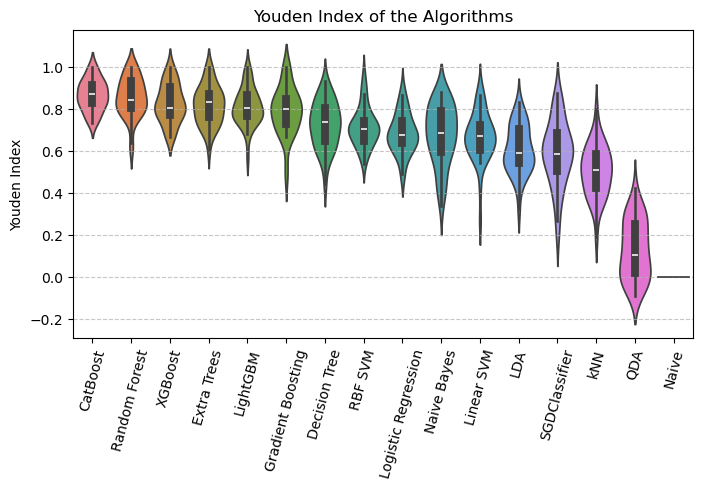

In [122]:
plot_youden_scores(youden_scores, exp_code='All', 
                   sorted=True, title='Youden Index of the Algorithms', 
                   experiment_tag=experiment_tag, savedir=outputdir)

### No Collinear Features

In [123]:
high_vif = get_high_vif(X, vif_threshold, verbosity)

In [124]:
# drop these features which seem to be collinear
high_vif_features = high_vif.feature.values.tolist()[1:]
high_vif_features

['SSA_L',
 'SSC_L',
 'SPSC_L',
 'CMAPANK_L',
 'CMAPKNE_L',
 'SSA_R',
 'SSC_R',
 'SPSA_R',
 'SPSC_R',
 'CMAPANK_R',
 'CMAPKNE_R']

In [125]:
Xnc = X.drop(columns=high_vif_features) #X no collinear
print(Xnc.shape) 
Xnc.head(2)

(190, 29)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SPSA_L,MCV_L,DL_L,FWAVE_L,MCV_R,DL_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,20.7,10.35,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,4.0,14.21,49.3,3.55,42.5,48.3,3.30,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [126]:
model_metrics['NoCol'] = benchmark_models(Xnc, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoCol'] = calculate_metric_statistics(model_metrics['NoCol'], sorting_metric=scoring)
metrics_stats['NoCol']['mean']

100%|██████████| 16/16 [01:03<00:00,  3.94s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Random Forest,0.843,0.867,0.914,0.690,0.604,0.889,0.908
CatBoost,0.835,0.859,0.912,0.668,0.581,0.884,0.911
LightGBM,0.825,0.865,0.885,0.695,0.580,0.874,0.896
XGBoost,0.826,0.858,0.896,0.673,0.569,0.876,0.899
Gradient Boosting,0.820,0.858,0.888,0.673,0.561,0.871,0.898
Extra Trees,0.815,0.843,0.899,0.633,0.533,0.870,0.882
Logistic Regression,0.802,0.845,0.872,0.650,0.522,0.857,0.863
LDA,0.784,0.840,0.846,0.650,0.496,0.842,0.855
Naive Bayes,0.730,0.887,0.703,0.788,0.491,0.760,0.868
Linear SVM,0.780,0.838,0.843,0.642,0.485,0.839,0.838


 -----

### No NCS

In [127]:
Xnncs = X.drop(columns=D.ncs_cols) #X no nerve conduction studies
print(D.ncs_cols)
Xnncs.shape, Xnncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']


((190, 22),
    SEX   AGE  SUBJ  DM_DUR  INSULIN  HBA1C  HPN  PAOD  DSLPDMIA  CKD  GBS  \
 0    1  64.0     1     7.0      1.0   15.0    0     0         0    0    0   
 1    0  59.0     1     1.0      0.0    5.6    1     0         0    0    0   
 
    DEC_VS  DEC_PPS  DEC_LTS  DEC_AR  MNSI  FEET_MEAN_ESC  FEET_PCT_ASYM  \
 0       1        1        1       1   9.0           12.0            0.0   
 1       0        0        0       0   4.0           39.0            5.0   
 
    HAND_MEAN_ESC  HAND_PCT_ASYM    NS   CAS  
 0           33.0           13.0  42.0  34.0  
 1           38.0           28.0  50.0  39.0  )

In [128]:
model_metrics['NoCS'] = benchmark_models(Xnncs, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoCS'] = calculate_metric_statistics(model_metrics['NoCS'], sorting_metric=scoring)
metrics_stats['NoCS']['mean']

100%|██████████| 16/16 [00:53<00:00,  3.37s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.803,0.821,0.912,0.567,0.479,0.864,0.817
LDA,0.776,0.832,0.845,0.627,0.472,0.837,0.800
Random Forest,0.799,0.819,0.910,0.560,0.470,0.861,0.819
Logistic Regression,0.782,0.821,0.874,0.582,0.456,0.845,0.792
RBF SVM,0.801,0.804,0.939,0.500,0.439,0.866,0.824
Linear SVM,0.761,0.812,0.849,0.570,0.419,0.828,0.775
Gradient Boosting,0.767,0.809,0.866,0.552,0.418,0.835,0.768
XGBoost,0.759,0.809,0.849,0.563,0.412,0.827,0.772
Extra Trees,0.766,0.803,0.873,0.533,0.406,0.836,0.805
LightGBM,0.755,0.805,0.849,0.553,0.402,0.825,0.765


 -----

### No Sudoscan Features

In [129]:
Xnsudo = X.drop(columns=D.sudo_cols) #X no nerve conduction studies
print(D.sudo_cols)
print(Xnsudo.shape)
Xnsudo.head(2)

['FEET_MEAN_ESC', 'FEET_PCT_ASYM', 'HAND_MEAN_ESC', 'HAND_PCT_ASYM', 'NS', 'CAS']
(190, 34)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3


In [130]:
model_metrics['NoSudo'] = benchmark_models(Xnsudo, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoSudo'] = calculate_metric_statistics(model_metrics['NoSudo'], sorting_metric=scoring)
metrics_stats['NoSudo']['mean']

100%|██████████| 16/16 [01:26<00:00,  5.42s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.946,0.962,0.960,0.917,0.877,0.961,0.974
Random Forest,0.941,0.953,0.962,0.895,0.857,0.957,0.971
XGBoost,0.929,0.945,0.952,0.877,0.829,0.948,0.966
LightGBM,0.923,0.940,0.949,0.867,0.816,0.944,0.965
Extra Trees,0.923,0.939,0.951,0.863,0.814,0.944,0.975
Gradient Boosting,0.912,0.930,0.945,0.840,0.785,0.936,0.958
RBF SVM,0.910,0.927,0.945,0.835,0.780,0.935,0.949
Decision Tree,0.882,0.924,0.905,0.832,0.736,0.912,0.868
Logistic Regression,0.887,0.914,0.924,0.808,0.732,0.918,0.935
Linear SVM,0.870,0.903,0.909,0.783,0.693,0.905,0.926


 -----

### No Neuro Features

In [131]:
Xnneuro = X.drop(columns=D.neuro_cols) #X no neuro columns
print(D.neuro_cols)
print(Xnneuro.shape) 
Xnneuro.head(2)

['DEC_VS', 'DEC_PPS', 'DEC_LTS', 'DEC_AR']
(190, 36)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [132]:
model_metrics['NoNeuro'] = benchmark_models(Xnneuro, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoNeuro'] = calculate_metric_statistics(model_metrics['NoNeuro'], sorting_metric=scoring)
metrics_stats['NoNeuro']['mean']

100%|██████████| 16/16 [01:18<00:00,  4.93s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.945,0.960,0.961,0.910,0.871,0.960,0.974
Random Forest,0.940,0.948,0.966,0.883,0.850,0.957,0.972
Extra Trees,0.931,0.947,0.954,0.882,0.836,0.950,0.975
XGBoost,0.925,0.940,0.954,0.863,0.817,0.946,0.969
LightGBM,0.922,0.939,0.949,0.865,0.814,0.943,0.965
Gradient Boosting,0.925,0.936,0.958,0.853,0.812,0.946,0.971
Decision Tree,0.890,0.917,0.925,0.813,0.738,0.920,0.869
RBF SVM,0.890,0.905,0.939,0.782,0.721,0.921,0.941
Logistic Regression,0.868,0.901,0.909,0.780,0.689,0.903,0.927
Linear SVM,0.863,0.904,0.898,0.788,0.686,0.899,0.916


 -----

### No Commorbidity Features

In [133]:
Xncom = X.drop(columns=D.comorbidity_cols) #X no neuro columns
print(D.comorbidity_cols)
print(Xncom.shape)
Xncom.head(2)

['HPN', 'PAOD', 'DSLPDMIA', 'CKD', 'GBS']
(190, 35)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [134]:
model_metrics['NoCom'] = benchmark_models(Xncom, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoCom'] = calculate_metric_statistics(model_metrics['NoCom'], sorting_metric=scoring)
metrics_stats['NoCom']['mean']

100%|██████████| 16/16 [01:16<00:00,  4.77s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.944,0.959,0.960,0.908,0.868,0.959,0.975
Random Forest,0.939,0.951,0.961,0.890,0.851,0.955,0.974
XGBoost,0.928,0.943,0.955,0.872,0.826,0.948,0.971
LightGBM,0.923,0.940,0.949,0.865,0.814,0.944,0.966
Extra Trees,0.923,0.940,0.949,0.865,0.814,0.944,0.976
Gradient Boosting,0.918,0.932,0.953,0.843,0.796,0.941,0.963
Naive Bayes,0.835,0.974,0.780,0.955,0.735,0.865,0.949
Decision Tree,0.879,0.913,0.914,0.805,0.719,0.912,0.859
RBF SVM,0.887,0.904,0.936,0.780,0.716,0.919,0.942
Logistic Regression,0.873,0.907,0.909,0.793,0.703,0.907,0.930


 -----

### No MNSI Feature

In [135]:
Xnmnsi = X.drop(columns=D.mnsi_col) #X no neuro columns
print(D.mnsi_col)
print(Xnmnsi.shape)
Xnmnsi.head(2)

['MNSI']
(190, 39)


,SEX,AGE,SUBJ,DM_DUR,INSULIN,HBA1C,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,1,64.0,1,7.0,1.0,15.0,0,0,0,0,0,1,1,1,1,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,0,59.0,1,1.0,0.0,5.6,1,0,0,0,0,0,0,0,0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [136]:
model_metrics['NoMSI'] = benchmark_models(Xnmnsi, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoMSI'] = calculate_metric_statistics(model_metrics['NoMSI'], sorting_metric=scoring)
metrics_stats['NoMSI']['mean']

100%|██████████| 16/16 [01:18<00:00,  4.91s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.943,0.958,0.960,0.907,0.867,0.959,0.974
Random Forest,0.940,0.953,0.961,0.895,0.856,0.956,0.969
XGBoost,0.926,0.940,0.955,0.863,0.819,0.947,0.968
LightGBM,0.922,0.941,0.947,0.868,0.815,0.943,0.963
Extra Trees,0.921,0.940,0.946,0.867,0.813,0.943,0.974
Gradient Boosting,0.917,0.933,0.949,0.848,0.798,0.940,0.968
Decision Tree,0.880,0.914,0.914,0.807,0.720,0.912,0.860
RBF SVM,0.889,0.903,0.941,0.777,0.718,0.921,0.940
Logistic Regression,0.870,0.901,0.911,0.780,0.691,0.905,0.928
Naive Bayes,0.808,0.956,0.754,0.927,0.680,0.838,0.929


 -----

### No Profile Feature

In [137]:
Xnprof = X.drop(columns=D.profile_cols) #X no neuro columns
print(D.profile_cols)
print(Xnprof.shape) 
Xnprof.head(2)

['SEX', 'AGE', 'SUBJ', 'DM_DUR', 'INSULIN', 'HBA1C']
(190, 34)


,HPN,PAOD,DSLPDMIA,CKD,GBS,DEC_VS,DEC_PPS,DEC_LTS,DEC_AR,MNSI,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,0,0,0,0,0,1,1,1,1,9.0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0,12.0,0.0,33.0,13.0,42.0,34.0
1,1,0,0,0,0,0,0,0,0,4.0,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3,39.0,5.0,38.0,28.0,50.0,39.0


In [138]:
model_metrics['NoProf'] = benchmark_models(Xnprof, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NoProf'] = calculate_metric_statistics(model_metrics['NoProf'], sorting_metric=scoring)
metrics_stats['NoProf']['mean']

100%|██████████| 16/16 [01:15<00:00,  4.69s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.940,0.957,0.956,0.905,0.861,0.956,0.967
Random Forest,0.942,0.954,0.962,0.897,0.859,0.958,0.968
Extra Trees,0.919,0.937,0.946,0.858,0.805,0.941,0.964
XGBoost,0.918,0.936,0.946,0.857,0.803,0.940,0.959
LightGBM,0.915,0.938,0.940,0.862,0.802,0.938,0.954
Gradient Boosting,0.915,0.930,0.949,0.840,0.789,0.939,0.964
RBF SVM,0.889,0.908,0.934,0.790,0.724,0.920,0.938
Decision Tree,0.877,0.912,0.910,0.805,0.715,0.910,0.857
Logistic Regression,0.869,0.902,0.908,0.783,0.691,0.904,0.922
Linear SVM,0.855,0.903,0.884,0.792,0.676,0.892,0.913


 -----

### NCS Only

In [139]:
Xncs = X[D.ncs_cols] #X nerve conduction studies
print(D.ncs_cols)
print(Xncs.shape) 
Xncs.head(2)

['SSA_L', 'SSC_L', 'SPSA_L', 'SPSC_L', 'MCV_L', 'DL_L', 'CMAPANK_L', 'CMAPKNE_L', 'FWAVE_L', 'SSA_R', 'SSC_R', 'SPSA_R', 'SPSC_R', 'MCV_R', 'DL_R', 'CMAPANK_R', 'CMAPKNE_R', 'FWAVE_R']
(190, 18)


,SSA_L,SSC_L,SPSA_L,SPSC_L,MCV_L,DL_L,CMAPANK_L,CMAPKNE_L,FWAVE_L,SSA_R,SSC_R,SPSA_R,SPSC_R,MCV_R,DL_R,CMAPANK_R,CMAPKNE_R,FWAVE_R
0,0.00,0.0,0.00,0.0,0.0,0.00,0.00,0.00,0.0,0.00,0.0,0.00,0.0,20.7,10.35,0.03,0.02,0.0
1,19.41,52.3,14.21,61.9,49.3,3.55,14.34,10.55,42.5,19.54,55.7,15.09,61.2,48.3,3.30,13.29,9.48,43.3


In [140]:
model_metrics['NCS'] = benchmark_models(Xncs, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['NCS'] = calculate_metric_statistics(model_metrics['NCS'], sorting_metric=scoring)
metrics_stats['NCS']['mean']

100%|██████████| 16/16 [01:03<00:00,  3.98s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
CatBoost,0.941,0.958,0.957,0.907,0.864,0.957,0.946
Extra Trees,0.937,0.957,0.952,0.905,0.857,0.954,0.949
Random Forest,0.937,0.953,0.957,0.895,0.852,0.954,0.946
kNN,0.921,0.949,0.936,0.887,0.823,0.942,0.936
RBF SVM,0.924,0.941,0.949,0.868,0.818,0.944,0.933
Linear SVM,0.909,0.953,0.913,0.900,0.813,0.932,0.936
Gradient Boosting,0.919,0.939,0.945,0.863,0.808,0.941,0.935
XGBoost,0.917,0.936,0.946,0.857,0.802,0.940,0.924
LightGBM,0.914,0.933,0.943,0.850,0.793,0.937,0.931
Logistic Regression,0.907,0.938,0.926,0.865,0.791,0.931,0.938


### Sudoscan Only Only

In [141]:
Xsudo = X[D.sudo_cols] 
print(Xsudo.shape) 
Xsudo.head(2)

(190, 6)


,FEET_MEAN_ESC,FEET_PCT_ASYM,HAND_MEAN_ESC,HAND_PCT_ASYM,NS,CAS
0,12.0,0.0,33.0,13.0,42.0,34.0
1,39.0,5.0,38.0,28.0,50.0,39.0


In [142]:
model_metrics['Sudo'] = benchmark_models(Xsudo, y, k_splits, n_repeats, random_seed, 0, experiment_tag)
metrics_stats['Sudo'] = calculate_metric_statistics(model_metrics['Sudo'], sorting_metric=scoring)
metrics_stats['Sudo']['mean']

100%|██████████| 16/16 [00:36<00:00,  2.27s/it]


,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Naive Bayes,0.734,0.775,0.865,0.452,0.316,0.816,0.720
Random Forest,0.732,0.769,0.868,0.435,0.303,0.815,0.701
CatBoost,0.731,0.758,0.891,0.383,0.275,0.819,0.700
Linear SVM,0.739,0.756,0.915,0.358,0.273,0.827,0.711
LDA,0.732,0.757,0.897,0.373,0.270,0.820,0.696
Extra Trees,0.720,0.759,0.868,0.400,0.268,0.809,0.687
Logistic Regression,0.734,0.753,0.912,0.348,0.261,0.824,0.695
LightGBM,0.699,0.760,0.818,0.442,0.259,0.786,0.646
Gradient Boosting,0.691,0.755,0.811,0.432,0.243,0.781,0.681
XGBoost,0.681,0.749,0.803,0.415,0.218,0.773,0.646


## Summary of Iterative Group Feature Elimination

In [143]:
model_metrics.keys(), metrics_stats.keys()

(dict_keys(['All', 'NoCol', 'NoCS', 'NoSudo', 'NoNeuro', 'NoCom', 'NoMSI', 'NoProf', 'NCS', 'Sudo']),
 dict_keys(['All', 'NoCol', 'NoCS', 'NoSudo', 'NoNeuro', 'NoCom', 'NoMSI', 'NoProf', 'NCS', 'Sudo']))

In [144]:
summary_metric = config.figures.summary_metric
summary_topk = config.figures.summary_table_topk

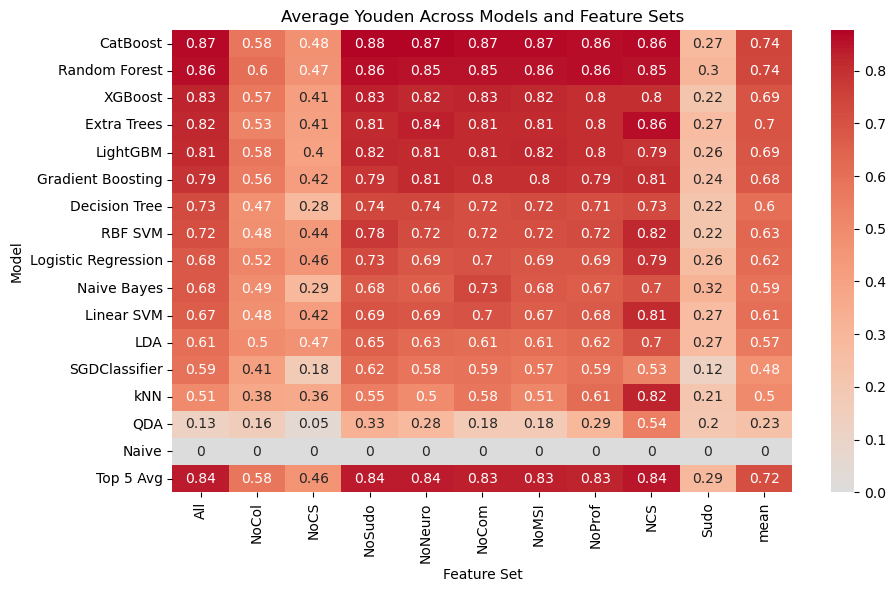

In [145]:
#del create_model_summary_table
from utils2.selection import *

# include all columns and stats
create_model_summary_table(metrics_stats,  outputdir, 
                           target_metric=scoring, 
                           topk=summary_topk, 
                           exclude_features=[],
                           include_mean=True, 
                           show_plot=True,
                           save_fig=True,
                           savename_suffix="");

In [146]:
# clean table without mean, topk
create_model_summary_table(metrics_stats,  outputdir, 
                           target_metric=scoring, 
                           topk=0, 
                           exclude_features=[],
                           include_mean=False, 
                           show_plot=False,
                           save_fig=True,
                           savename_suffix="");

 -----

## Save the Metrics to a Pickle File

In [147]:
# save results 
joblib.dump(model_metrics, outputdir / "model_metrics.pkl")
joblib.dump(metrics_stats, outputdir / "metrics_stats.pkl")
joblib.dump(youden_scores, outputdir / "youden_scores.pkl");

 -----

## Load Save Results and Verify

In [148]:
# Verify saved results
loaded_model_metrics = joblib.load(outputdir / "model_metrics.pkl")
calculate_metric_statistics(loaded_model_metrics['All'])

{'mean':                      accuracy  precision  sensitivity  specificity  youden  \
 Naive                   0.684      0.684        1.000        0.000   0.000   
 Logistic Regression     0.866      0.899        0.908        0.777   0.684   
 LDA                     0.832      0.877        0.878        0.730   0.608   
 QDA                     0.682      0.721        0.885        0.245   0.130   
 SGDClassifier           0.807      0.901        0.825        0.767   0.592   
 Decision Tree           0.880      0.917        0.911        0.815   0.726   
 Random Forest           0.941      0.954        0.961        0.897   0.858   
 Extra Trees             0.924      0.942        0.949        0.870   0.819   
 Gradient Boosting       0.917      0.931        0.953        0.840   0.793   
 XGBoost                 0.929      0.943        0.955        0.872   0.827   
 LightGBM                0.922      0.939        0.948        0.865   0.813   
 CatBoost                0.943      0.958   

In [149]:
loaded_metric_stats = joblib.load(outputdir / "metrics_stats.pkl")
loaded_metric_stats['All']['std']

,accuracy,precision,sensitivity,specificity,youden,f1,roc-auc
Naive,0.003,0.003,0.000,0.000,0.000,0.002,0.000
Logistic Regression,0.045,0.034,0.058,0.083,0.096,0.035,0.032
LDA,0.050,0.040,0.055,0.094,0.114,0.038,0.044
QDA,0.050,0.042,0.089,0.181,0.140,0.039,0.053
SGDClassifier,0.069,0.077,0.147,0.223,0.154,0.072,0.041
Decision Tree,0.046,0.044,0.057,0.107,0.111,0.035,0.056
Random Forest,0.036,0.037,0.035,0.087,0.093,0.026,0.018
Extra Trees,0.037,0.035,0.036,0.083,0.092,0.027,0.019
Gradient Boosting,0.042,0.046,0.044,0.116,0.115,0.030,0.028
XGBoost,0.036,0.037,0.037,0.086,0.092,0.026,0.021


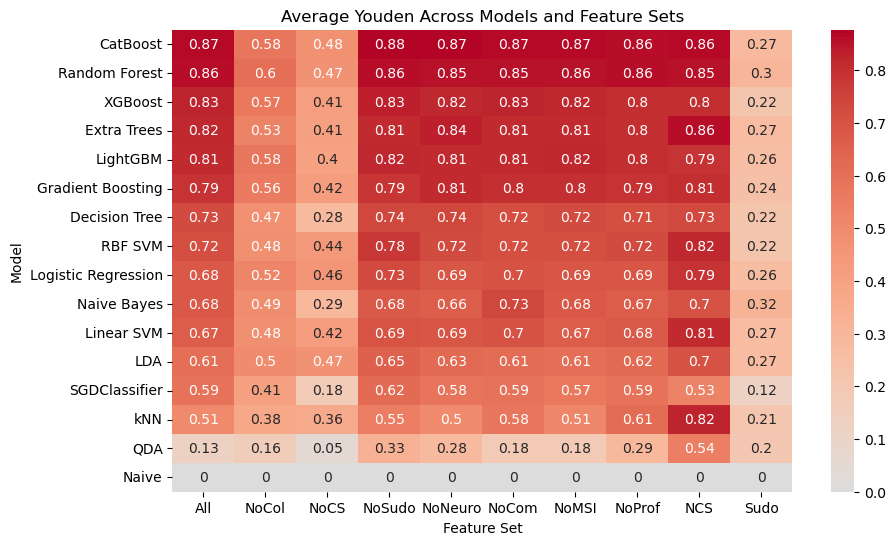

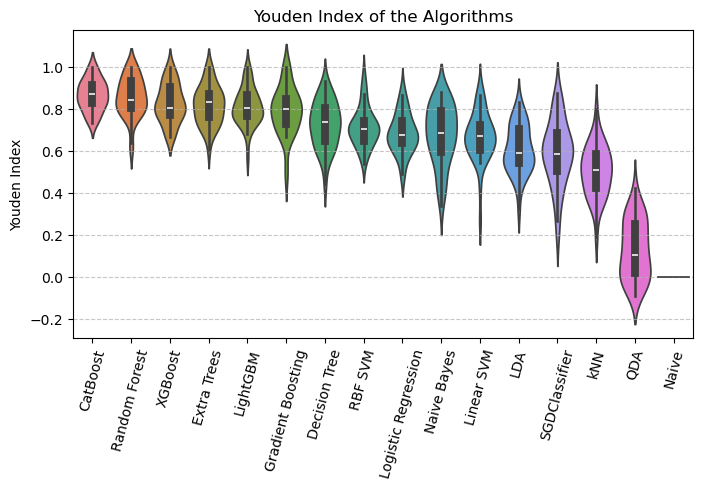

In [150]:
loaded_youden_scores = joblib.load(outputdir / "youden_scores.pkl")

plot_youden_scores(loaded_youden_scores, exp_code='All', 
                   sorted=True, title='Youden Index of the Algorithms', 
                   experiment_tag=experiment_tag, savedir=outputdir)

 -----